In [2]:
%cd ../.
import os, sys
sys.path.insert(0, os.path.abspath('../Scripts'))

/home/gtamo/MS_ML


In [3]:
%load_ext autoreload
%autoreload 2

import re
import os
import pandas as pd
import numpy as np
import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import csv
import pickle

from pathlib import Path
from rdkit import Chem
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm import tqdm
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from xgboost import XGBClassifier,XGBRegressor
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns
from scipy import stats
import pyarrow.dataset as pads
import csv, contextlib, threading, joblib
import joblib
from joblib import Parallel, delayed
from datetime import date

# user defined modules
import Rdkit_tools as rdkit_tools
importlib.reload(rdkit_tools)
import Molecule as M
import ML_Reg as ML_Reg
import ML_Class as ML_Class
from MolViz3D import MolViz3D
import Statistics_tools as stats_tools
import python.functions as fn
import python.MS_ML_prioritization as mlp
# from tdc.multi_pred import DTI

## 0. Imports

In [4]:
## params — single source of truth in config/config.yaml.
## Loaded as a `config` namespace AND injected as globals, so both
## `config.RAW_PROTEOMICS_PATH` and bare `RAW_PROTEOMICS_PATH` work.
import yaml
from types import SimpleNamespace
with open('config/config.yaml') as _f:
    _cfg = yaml.safe_load(_f)
config = SimpleNamespace(**_cfg)
globals().update(_cfg)
print(f'> loaded {len(_cfg)} params from config/config.yaml')


> loaded 49 params from config/config.yaml


#### 20260528 - Prioritizing virtual & library compounds vs PCSK9
We will use the 20260513 trained models to proritize compounds coming from a virtual enumeration and unscreen compounds from our library

In [ ]:
## get enamine virtual enum - convert sdf to smiles and extract relevant fields/columns
enum_df = rdkit_tools.get_smiles_df_from_enum(ENAMINE_20260513)
enum_df['compound']  = enum_df['R1_Code'] + '_' + enum_df['R2_Code']
enum_df['filename'] = Path(ENAMINE_20260513).stem
enum_df['smiles'] = enum_df['smiles'].progress_apply(lambda x: rdkit_tools.convert_smiles_to_canonical(x))
enum_df.head(1)

In [ ]:
## get unscreened library:
lib = pd.read_csv(PX_SCREEN_LIB).rename(columns={'Molecule Name':'compound','SMILES':'smiles','Lib ID':'lib_id','Px_screened_source':'source'})
lib['smiles'] = lib['smiles'].progress_apply(lambda x: rdkit_tools.convert_smiles_to_canonical(x))
print(lib['Px_screened_anywhere'].unique())
lib['Px_sreened'] = 0
lib.loc[lib['Px_screened_anywhere']=='yes','Px_sreened'] = 1
lib = lib[['compound','smiles','lib_id','source','Px_sreened']]

# select uncreened compounds from enamine 4 lib id
# lib = lib[ (lib['lib_id']=='Enamine 4') & (lib['Px_sreened']==0) ]
# print(lib.shape)
# lib.head(1)

# get all the screened compounds:
Px_screened_smiles = list(lib[lib['Px_sreened']==1]['smiles'])
len(Px_screened_smiles)

In [ ]:
## remove anything that could have been screened from the enumeration:
print(f"before {enum_df.shape}")
enum_df = enum_df[~enum_df['smiles'].isin(Px_screened_smiles)]
print(f"after {enum_df.shape}")

In [ ]:
## prioritize compounds:
## Implementation now lives in Scripts/ML_Reg.py (ML_Reg.MLReg_prioritize_compounds).
## The function loads a joblib bundle, computes H236 features on `ori_data`, and
## returns the top-N most-active compounds. See its docstring for details.
model_path = 'output/ML/trained_models/20260513/PCSK9_RF_H236.joblib'

pred_df = ML_Reg.MLReg_prioritize_compounds(
    ori_data=enum_df,
    model=model_path,
    top=300,
    features_n=None,        # use the bundle's saved featurizer name
)


In [ ]:
test_outpath = DROPBOX_ML+'predictions/20260518_enum_NAr-pyrimidine_Enamine_4_pred.sdf'
pred_df

## Sanity check: SMILES intersection between the written SDF and pred_df
from rdkit import Chem

# 1) Read back what we wrote
out_df = rdkit_tools.get_smiles_df_from_enum(test_outpath)

# 2) Re-canonicalize both sides defensively — different code paths
#    (MolToSmiles in get_smiles_df_from_enum vs convert_smiles_to_canonical
#    upstream of pred_df) usually agree, but a one-pass re-canonicalisation
#    eliminates any kekulization / stereo-perception drift.
def _canon(smi):
    if not isinstance(smi, str) or not smi:
        return None
    m = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(m) if m is not None else None

out_smis  = set(out_df['smiles'].map(_canon).dropna())
pred_smis = set(pred_df['smiles'].map(_canon).dropna())

inter      = out_smis & pred_smis
only_in_out  = out_smis - pred_smis
only_in_pred = pred_smis - out_smis

print(f'SDF written         : {len(out_df):,} rows  ({len(out_smis):,} unique canonical SMILES)')
print(f'pred_df             : {len(pred_df):,} rows ({len(pred_smis):,} unique canonical SMILES)')
print(f'∩ (intersection)    : {len(inter):,}')
print(f'in SDF, NOT in pred : {len(only_in_out):,}')
print(f'in pred, NOT in SDF : {len(only_in_pred):,}')




In [ ]:
## write sdf in dropbox folder:
if pred_df.shape[0] > 0:
    n = rdkit_tools.write_filtered_enum_sdf(
        pred_df,
        source_dir=DROPBOX_ML+'virtual libraries', # exact path to sdf file which let's copy verbatim the stereochemistry and attributes
        out_path=DROPBOX_ML+'predictions/20260518_enum_NAr-pyrimidine_Enamine_4_pred.sdf',
        pred_col='predicted_label',
)

#### Prioritize 150 compounds from 114 virtual enumeration

In [ ]:
## get 114 virtual enumerations:
enumpath = 'data/enumeration/20260427/'
enum_fs = glob(enumpath+'*')

# get a unified file for prediction:
# combined_sdf, n_parts = rdkit_tools.combine_sdfs(enumpath, '20260518_114K_enum.sdf')
enum114_df = rdkit_tools.get_smiles_df_from_enum_dir(enumpath, v=True)
print(f'> parsed {enum114_df["filename"].nunique()} SDFs, {len(enum114_df):,} rows total')


# get smiles from this:
enum114_df['compound']  = enum114_df['R1_Code'] + '_' + enum114_df['R2_Code']
enum114_df['smiles'] = enum114_df['smiles'].progress_apply(lambda x: rdkit_tools.convert_smiles_to_canonical(x))
enum114_df = enum114_df.drop_duplicates('smiles').reset_index(drop=True)

## remove compounds already present in other sets:
cm2rm = list(enum_df['smiles']) + Px_screened_smiles
print(f"before {enum114_df.shape}")
enum114_df = enum114_df[~enum114_df['smiles'].isin(cm2rm)]
print(f"before {enum114_df.shape}")


In [ ]:
## prioritize compounds:
pred114_df = ML_Reg.MLReg_prioritize_compounds(
    ori_data=enum114_df,
    model='output/ML/trained_models/20260513/PCSK9_RF_H236.joblib',
    top=300,
    features_n=None,        # use the bundle's saved featurizer name
    verbose=True,
)

In [ ]:
## write sdf in dropbox folder:
if pred114_df.shape[0] > 0:
    n = rdkit_tools.write_filtered_enum_sdf(
        pred114_df,
        source_dir='data/enumeration/20260427/', # exact path to sdf file which let's copy verbatim the stereochemistry and attributes
        out_path=DROPBOX_ML+'predictions/20260518_Enamine_114k_pred.sdf',
        pred_col='predicted_label',
)

#### 20260608 Re-Prioritize these compounds based on curated data
We remove all compounds that are found to be FBX indepent downmodulation as well as not validation in n=2

In [ ]:
## get 114 virtual enumerations:
enum750k_df = pd.read_csv('data/enumeration/20260608/Serac scaffolds broad enumeration.csv', sep='\t',).rename(columns={'SMILES':'smiles'})
enum750k_df['compound'] = 'X'+enum750k_df.index.astype(str)
enum750k_df.head(1)

,smiles,RSN,compound
0,C#CC#CC(C)(C)NC(=O)COc1ccc2c(c1)[C@@H]1CNC(=O)...,m11____20028868____117735006,X0


In [ ]:
%%time 
## get 114 virtual enumerations:
enum750k_df = pd.read_csv('data/enumeration/20260608_PCSK9/Serac scaffolds broad enumeration.csv', sep='\t',).rename(columns={'SMILES':'smiles'})
enum750k_df['compound'] = 'X'+enum750k_df.index.astype(str)

# # enum114_df['smiles'] = enum114_df['smiles'].progress_apply(lambda x: rdkit_tools.convert_smiles_to_canonical(x))

# ## prioritize compounds:
# pred114_df = ML_Reg.MLReg_prioritize_compounds(
#     ori_data=enum750k_df,
#     # model='output/ML/trained_models/20260513/PCSK9_RF_H236.joblib',
#     model='output/ML/trained_models/20260608_PCSK9/PCSK9_RF_H236.joblib',
#     top=1000,
#     features_n=None,        # use the bundle's saved featurizer name
#     verbose=True,
# )

> loading bundle: gene=PCSK9  R²=0.147  features=H236  (2529 cols)
> featurising 758,691 unique compounds via compute_H236_features...


predicting: 100%|██████████| 21/21 [00:08<00:00,  2.41chunk/s]


> PCSK9  R²=0.147  features=H236  (2529 cols)  predicted 758,691 unique / 758,691 rows; top 1000
CPU times: user 32min 46s, sys: 21.6 s, total: 33min 8s
Wall time: 1h 1min 9s


In [79]:
pred114_df.head(1)

,smiles,RSN,compound,predicted_label
0,COC(=O)N1[C@H]2Cc3ccc(-c4ccnc(NCC5CCN(c6cc(Cl)...,m27____2757582____117711006,X305996,-1.187251


In [82]:
## write sdf in dropbox folder (SMILES-only, no template):
## tag_cols = the fields to embed as SDF tags (one each). 'compound' becomes the
## molecule title automatically. pred_col is just the single-tag shortcut for
## TEMPLATE mode; in SMILES-only mode use tag_cols for one-or-many fields.
if pred114_df.shape[0] > 0:
    n = rdkit_tools.write_filtered_enum_sdf(
        pred114_df,
        out_path=DROPBOX_ML+'20260608_Echoes_PCSK9_750k_enamine.sdf',
        tag_cols=['RSN', 'predicted_label'],
    )
    print(f'wrote {n} records')


wrote 1000 records


#### 20260622 Prioritize compounds to hit ['PCSK9','TGFB1','EPHB4','BRD2','ANGPTL4'] and that are Single / Low

##### Params

In [5]:
## params:
# out
enum     = 'data/enumeration/20260608_5Targets_SingleLow/Serac scaffolds broad enumeration_filtered.csv' # input
outMFsmi = 'output/enumeration/20260608_5Targets_SingleLow/MF_features_H236_full.parquet' # MF_features
out550k  = 'output/enumeration/20260608_5Targets_SingleLow/pred_logfc_select_genes.parquet' # the predicted logfc per target
out_sl   = 'output/enumeration/20260608_5Targets_SingleLow/pred_single_low.parquet'
# ml models
SELECT_GENES_DIR = 'output/ML/trained_models/20260617_select_genes' # the ML trained model per gene
SINGLELOW_MODEL  = 'output/ML/trained_models/20260623_SingleLow_Class/SingleLow_RF.joblib' # the ML model to predict single/low

In [7]:
## get 114 virtual enumerations:
enum550k_df = pd.read_csv(enum, sep=',',).rename(columns={'mol_smi':'smiles'})
enum550k_df['compound'] = 'X'+enum550k_df.index.astype(str)
print(enum550k_df.shape)
enum550k_df.head(1)

(456856, 7)


,RSN,smiles,MW,TPSA,N_rotatable_bonds,cLogP,compound
0,m2430____26826022____117713022,C#CC#CC(C)(C)NC(=O)N1CC(Cn2cnc3cc4c(cc32)[C@@H...,488.22,108.8,4.0,1.26,X0


##### Prediction

In [ ]:
## compute the FULL H236 feature universe + cache it (one expensive pass over the library).
## Do NOT prevalence-drop here: each trained model carries its own prevalence-filtered
## `feature_cols` (cut on its TRAINING set), and the prediction cell selects them per-model.
## A 550K-derived prevalence cut does NOT match the models' columns (it drops ~91 Morgan bits
## the models need -> KeyError). compute_H236_features already returns the full universe
## (F0..F2047 + physchem + MACCS + AP_0..AP2047), so feature selection is a downstream step.
if not os.path.exists(outMFsmi):
    MF_features = rdkit_tools.compute_H236_features(enum550k_df, v=True)
    MF_features = enum550k_df[['compound', 'smiles']].merge(MF_features, on='compound').drop_duplicates('compound')
    MF_features.to_parquet(outMFsmi, index=False)
else:
    MF_features = pd.read_parquet(outMFsmi)
print(MF_features.shape)

H236 features: 100%|██████████| 456856/456856 [12:43<00:00, 598.47it/s]


(456856, 4271)


In [ ]:
## predict logfc/probabilities with each model
## RandomForest *regressors* (one per gene) -> each predicts a continuous logfc.
## Each bundle carries its own prevalence-filtered `feature_cols` (a subset of the full
## H236 universe in MF_features); select per-model, then predict. Features are computed
## once (cell above) and reused, so no 5x re-featurisation of the library.

pred550k_df = MF_features[['compound', 'smiles']].copy()
_Xkey = _X = None
for mp in sorted(glob(os.path.join(SELECT_GENES_DIR, '*.joblib'))):
    b = joblib.load(mp)
    gene, fcols = b['gene'], b['feature_cols']
    missing = [c for c in fcols if c not in MF_features.columns]
    assert not missing, f"{gene}: {len(missing)} feature_cols missing from MF_features (regenerate the full-universe cache); e.g. {missing[:5]}"
    if tuple(fcols) != _Xkey:                      # rebuild only when feature_cols change; keep
        _Xkey, _X = tuple(fcols), MF_features[fcols]   # column NAMES so sklearn validates alignment
    pred550k_df[gene] = b['model'].predict(_X)
    print(f"> {gene:8s} ({b.get('features')}, {len(fcols)} cols, n_train={b.get('n_train')}): "
          f"pred logfc [{pred550k_df[gene].min():.2f}, {pred550k_df[gene].max():.2f}] mean {pred550k_df[gene].mean():.2f}")

gene_cols = [c for c in pred550k_df.columns if c not in ('compound', 'smiles')]

pred550k_df.to_parquet(out550k, index=False)
print(f"\n> saved {len(pred550k_df):,} compounds x {len(gene_cols)} gene logfc predictions -> {out550k}")
pred550k_df[['compound'] + gene_cols].head()

> ANGPTL4  (prevalence, 2535 cols, n_train=1719): pred logfc [-0.56, 0.40] mean -0.03
> BRD2     (prevalence, 2535 cols, n_train=1817): pred logfc [-0.23, 0.17] mean 0.00
> EPHB4    (prevalence, 2535 cols, n_train=1817): pred logfc [-0.34, 0.24] mean 0.04
> PCSK9    (prevalence, 2535 cols, n_train=1817): pred logfc [-1.15, 0.44] mean -0.04
> TGFB1    (prevalence, 2535 cols, n_train=1817): pred logfc [-0.50, 0.83] mean -0.01

> saved 456,856 compounds x 5 gene logfc predictions -> output/enumeration/20260608_5Targets_SingleLow/pred_logfc_select_genes.parquet


,compound,ANGPTL4,BRD2,EPHB4,PCSK9,TGFB1
0,X0,0.055033,0.047835,0.065441,-0.035161,-0.051939
1,X1,0.005707,0.048097,0.028039,-0.130816,-0.018298
2,X2,0.037101,0.010966,0.026642,-0.067577,0.037803
3,X3,-0.001770,0.057640,0.063994,0.036845,-0.022178
4,X4,0.001355,0.047139,0.054911,-0.011529,0.010861


In [ ]:
## predict + prioritize single/low (classifier) on the 550K — same full-H236 deploy pattern
## Loads the SingleLow bundle, selects its feature_cols from the full H236 universe (MF_features),
## ranks compounds by P(single/low). NOTE: classifier -> predict_proba[:, 1], not predict.

_b = joblib.load(SINGLELOW_MODEL)
_fcols = _b['feature_cols']
_missing = [c for c in _fcols if c not in MF_features.columns]
assert not _missing, f"{len(_missing)} feature_cols missing from MF_features (regenerate the full-universe cache); e.g. {_missing[:5]}"

pred_singlelow_df = MF_features[['compound', 'smiles']].copy()
pred_singlelow_df['p_single_low'] = _b['model'].predict_proba(MF_features[_fcols])[:, 1]   # named df -> sklearn validates cols
pred_singlelow_df = pred_singlelow_df.sort_values('p_single_low', ascending=False).reset_index(drop=True)

pred_singlelow_df.to_parquet(out_sl, index=False)
print(f"> {_b['task']} ({_b.get('features')}, {len(_fcols)} cols, n_train={_b.get('n_train')}): "
      f"P(single/low) range [{pred_singlelow_df['p_single_low'].min():.2f}, {pred_singlelow_df['p_single_low'].max():.2f}] "
      f"mean {pred_singlelow_df['p_single_low'].mean():.2f}")
print(f"> saved {len(pred_singlelow_df):,} ranked compounds -> {out_sl}")
pred_singlelow_df[['compound', 'p_single_low']].head()

> single_low_vs_rest (H236, 2535 cols, n_train=2579): P(single/low) range [0.10, 0.96] mean 0.68
> saved 456,856 ranked compounds -> output/enumeration/20260608_5Targets_SingleLow/pred_single_low.parquet


,compound,p_single_low
0,X170444,0.9600
1,X347741,0.9575
2,X169019,0.9500
3,X183234,0.9500
4,X248979,0.9475


##### Prioritization using all targets/labels

In [8]:
pred550k_df = pd.read_parquet(out550k)
pred_singlelow_df = pd.read_parquet(out_sl)

final_pred = pd.merge(pred550k_df,pred_singlelow_df[['compound','smiles', 'p_single_low']])
final_pred = pd.merge(enum550k_df[['smiles','RSN']],final_pred)
print(final_pred.shape)
final_pred.head(1)

(457460, 9)


,smiles,RSN,compound,ANGPTL4,BRD2,EPHB4,PCSK9,TGFB1,p_single_low
0,C#CC#CC(C)(C)NC(=O)N1CC(Cn2cnc3cc4c(cc32)[C@@H...,m2430____26826022____117713022,X0,0.055033,0.047835,0.065441,-0.035161,-0.051939,0.733433


In [15]:
## get Pareto optimal points
prio_all = stats_tools.top_k_pareto(
    final_pred, objectives=['ANGPTL4','BRD2','EPHB4','PCSK9','TGFB1','p_single_low'],
    k=1000, directions={'p_single_low': 'max'})   # the 5 logfc default to 'min'
prio_all.head(2)

,pareto_front,smiles,RSN,compound,ANGPTL4,BRD2,EPHB4,PCSK9,TGFB1,p_single_low
170678,1,COC(=O)N1[C@H]2Cc3ccc(-c4ccnc(N5CCN(C)C6(CCC6)...,m27____25523470____117711006,X170444,0.264704,0.106990,0.195550,0.295957,-0.042682,0.9600
169510,1,COC(=O)N1[C@H]2Cc3ccc(-c4ccnc(N5CCCC(Cc6cccc(O...,m27____41383104____117711006,X169276,-0.558831,-0.135271,-0.102659,-0.485291,0.344322,0.6675


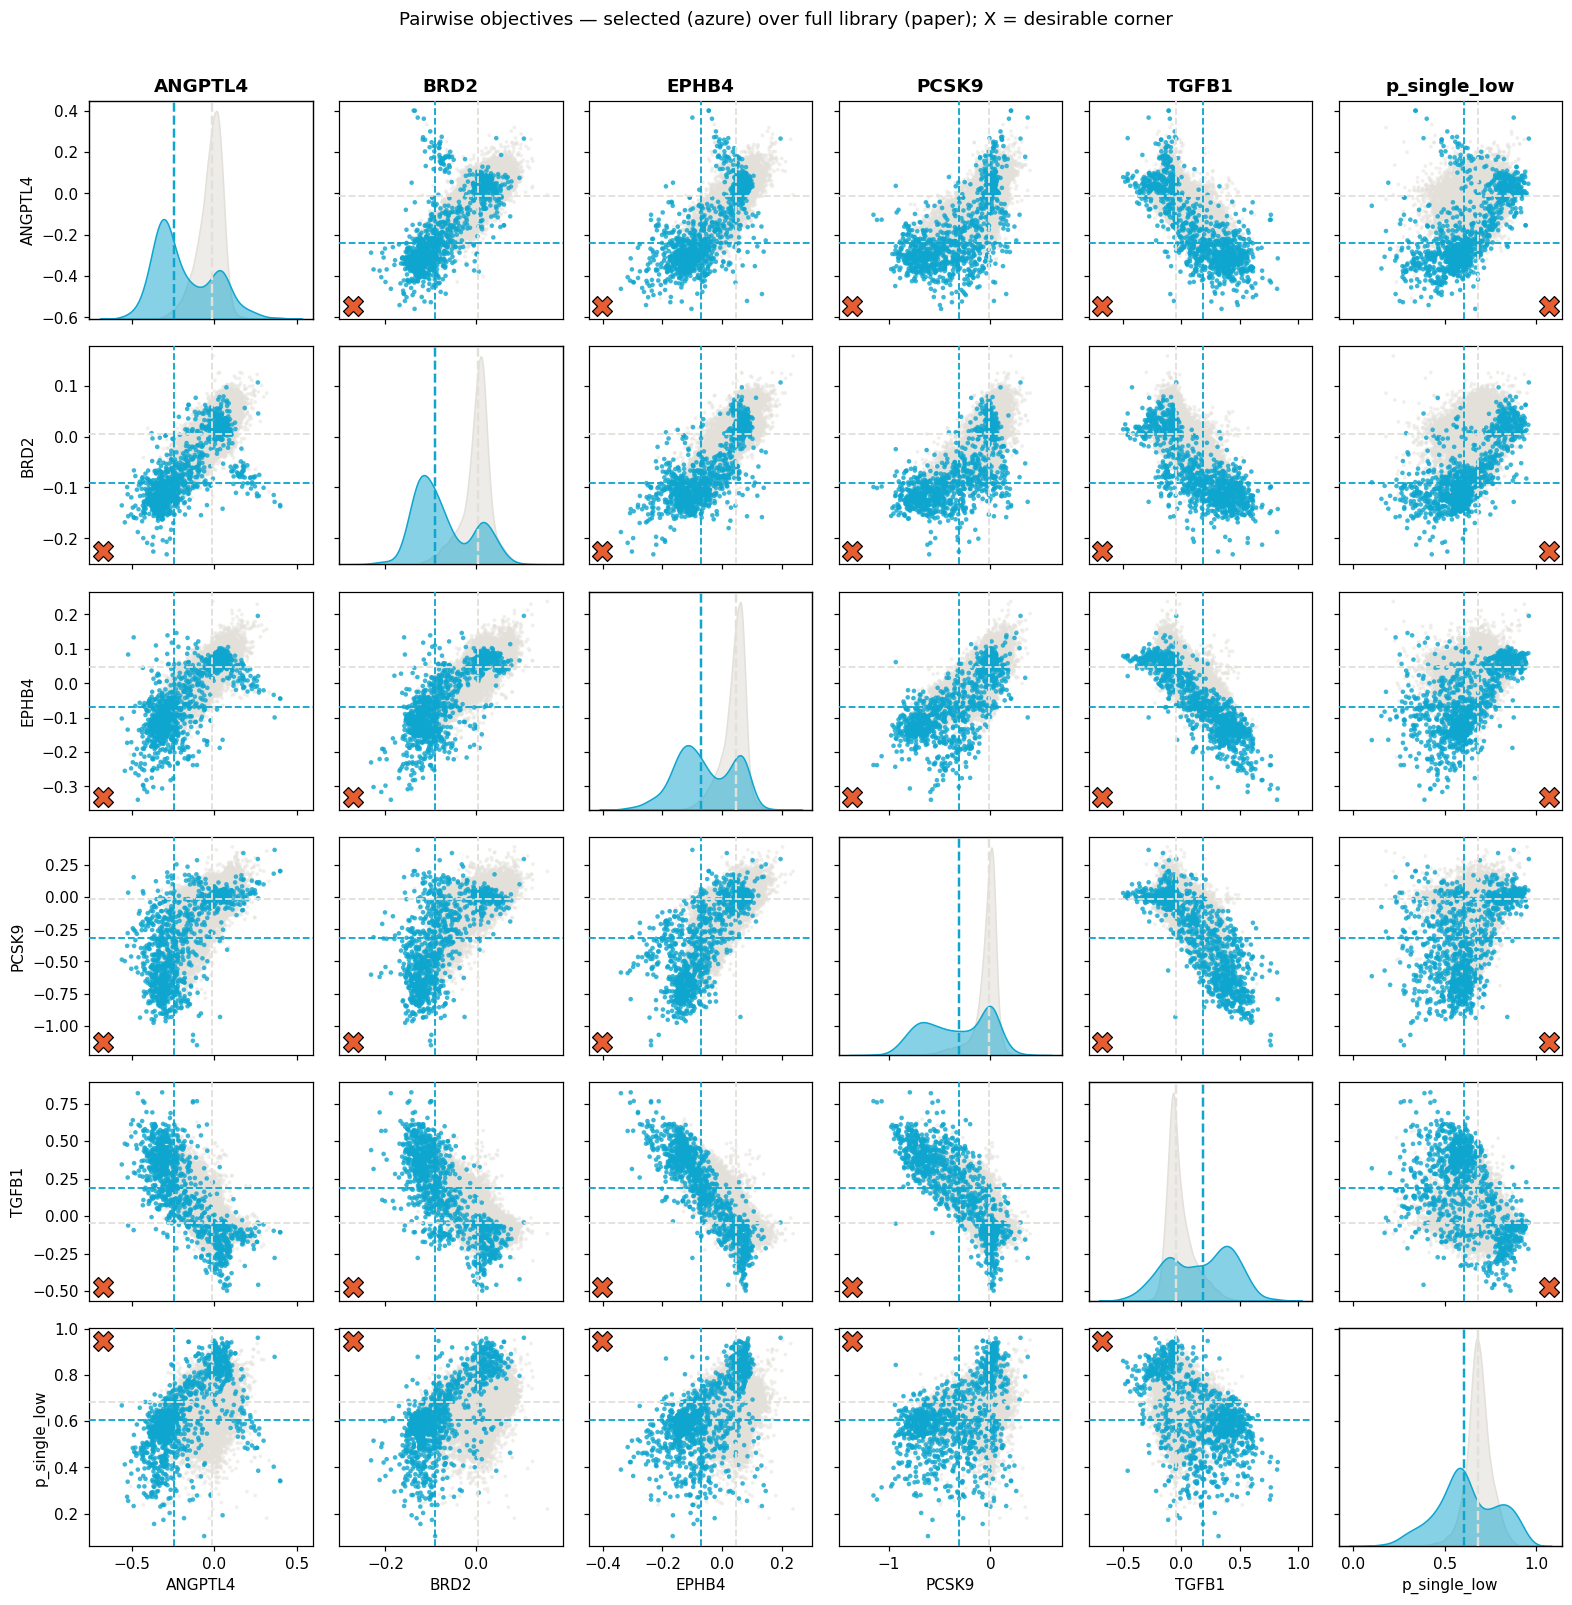

In [16]:
## Pairwise scatter matrix: selected top-1000 (azure) over full library (paper).
_objs = ['ANGPTL4', 'BRD2', 'EPHB4', 'PCSK9', 'TGFB1', 'p_single_low']
mlp.plot_pairwise_matrix(_objs, final_pred, prio_all, colors=SERAC_C);

In [17]:
## Visualize directionality: per-objective KDE overlay (full library vs Pareto selections).
_objs = ['ANGPTL4', 'BRD2', 'EPHB4', 'PCSK9', 'TGFB1', 'p_single_low']
mlp.plot_objective_kde(
    _objs,
    [final_pred, prio_all, prio_noTGF],
    [SERAC_C['paper'], SERAC_C['azure'], SERAC_C['ember']],
    ['lib', 'with TGFB1', 'without TGFB1'],
);

NameError: name 'prio_noTGF' is not defined

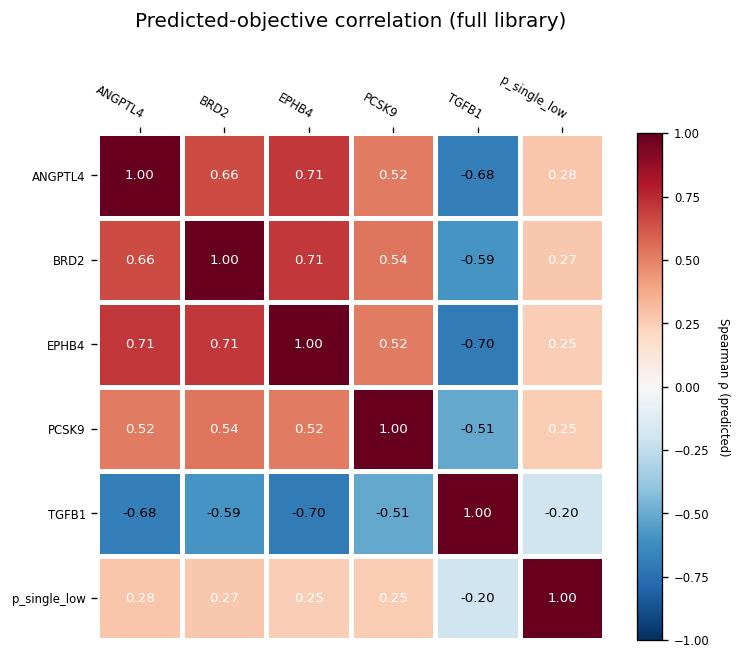

In [ ]:
## Covariance analysis: Spearman correlation of the predicted objectives.
_objs = ['ANGPTL4', 'BRD2', 'EPHB4', 'PCSK9', 'TGFB1', 'p_single_low']
_fig, _corr = mlp.plot_objective_correlation(_objs, final_pred)

##### Prioritization removing TGFB1

In [21]:
## get Pareto optimal points
_objs = ['ANGPTL4', 'BRD2', 'EPHB4', 'PCSK9', 'p_single_low']
prio_noTGF = stats_tools.top_k_pareto(
    final_pred[final_pred['p_single_low']>0.63], objectives=_objs, # 
    k=800, directions={'p_single_low': 'max'})   # the 5 logfc default to 'min'
prio_noTGF.head(2)

,pareto_front,smiles,RSN,compound,ANGPTL4,BRD2,EPHB4,PCSK9,TGFB1,p_single_low
146729,1,COC(=O)N1[C@H]2Cc3ccc(-c4ccnc(N5C[C@@H]6[C@H]7...,m27____22601324____117711006,X172323,0.366278,-0.128317,-0.099630,0.366764,-0.279543,0.877500
303286,1,COC(=O)N1[C@H]2Cc3cccc(OC4CN(Cc5cc(F)ccc5Oc5cc...,m270004____117705006____13024860,X354936,-0.369658,-0.142015,-0.107749,-0.258824,0.445216,0.630933


In [ ]:
# ## Pairwise scatter matrix: selected top-1000 (azure) over full library (paper).
# mlp.plot_pairwise_matrix(_objs, final_pred, prio_noTGF, colors=SERAC_C);

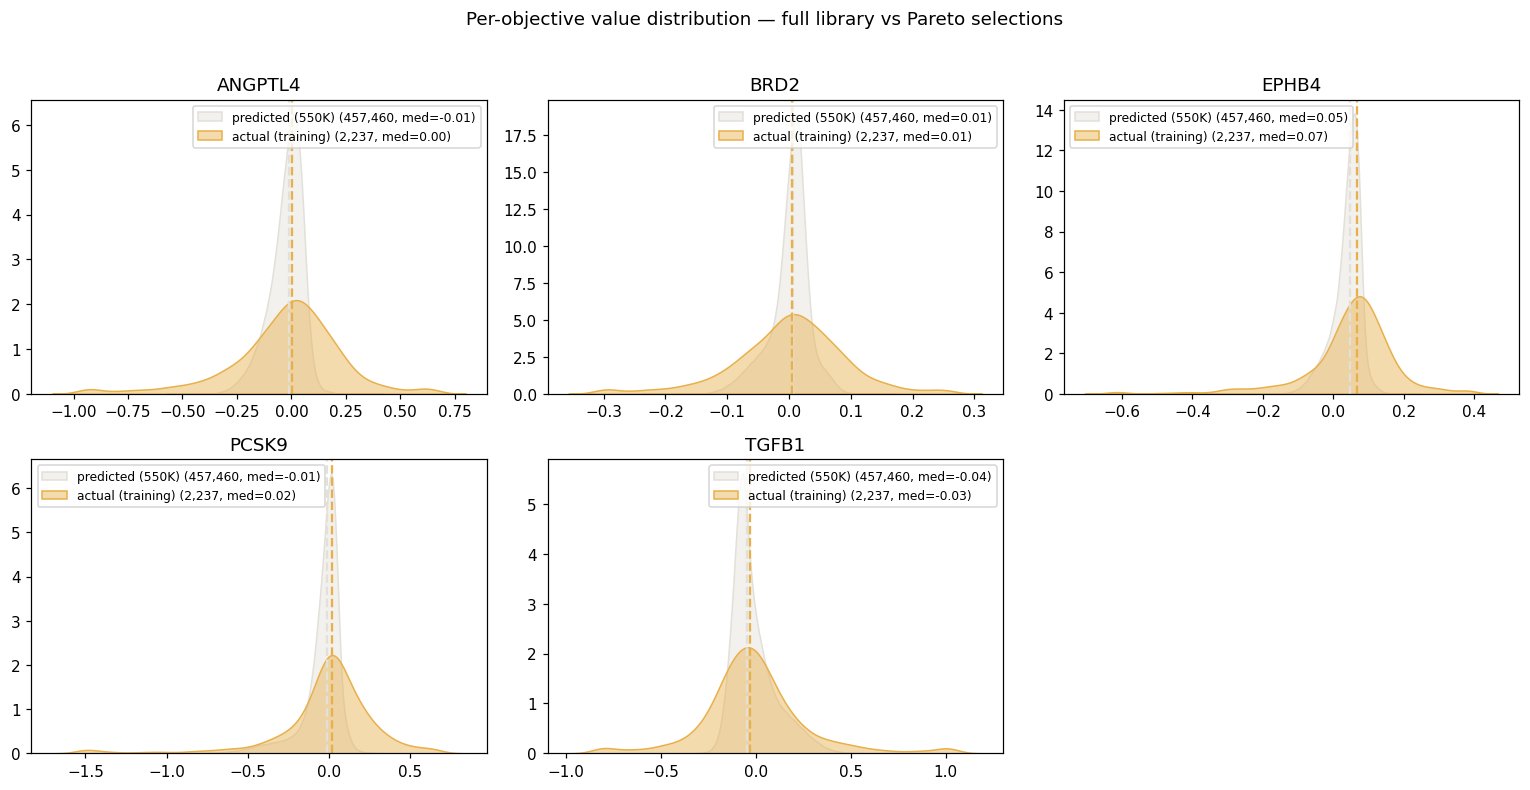

In [ ]:
## plot logfc distribution of actual proteomics (df_raw): predicted (550K) vs actual training labels.
## 'actual' uses the exact training transform (per-gene 1-99% winsorize -> compound-level mean).
_g5 = ['ANGPTL4', 'BRD2', 'EPHB4', 'PCSK9', 'TGFB1']
_raw = pads.dataset(
    'autoresearch/optimize_SingleLow_Classification/20260622_df_raw.parquet', format='parquet'
).to_table(columns=['compound', 'genes', 'logfc'], filter=pads.field('genes').isin(_g5)).to_pandas()

_actual = {}
for g in _g5:
    sub = _raw[_raw['genes'] == g]
    lo, hi = np.nanpercentile(sub['logfc'].dropna(), [1, 99])
    _actual[g] = sub.assign(l=sub['logfc'].clip(lo, hi)).groupby('compound')['l'].mean()
actual_logfc = pd.DataFrame(_actual)   # wide: one col per target (compound sets differ -> NaN, fine for KDE)

mlp.plot_objective_kde(_g5, [final_pred, actual_logfc],
                       [SERAC_C['paper'], SERAC_C['gold']],
                       ['predicted (550K)', 'actual (training)']);

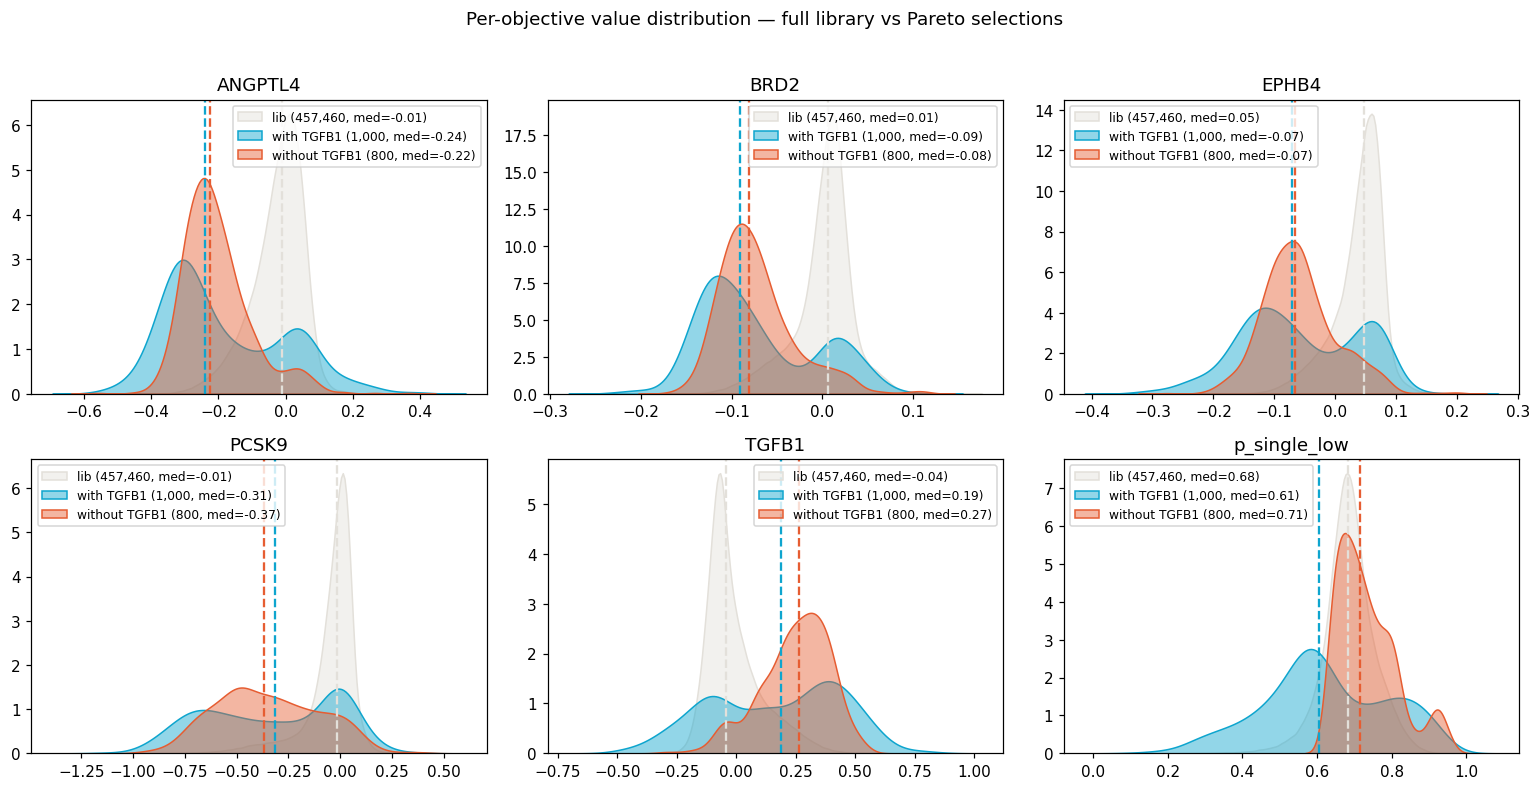

In [ ]:
## Visualize directionality: per-objective KDE overlay (full library vs Pareto selections).
_objs = ['ANGPTL4', 'BRD2', 'EPHB4', 'PCSK9', 'TGFB1', 'p_single_low']
mlp.plot_objective_kde(
    _objs,
    [final_pred, prio_all, prio_noTGF],
    [SERAC_C['paper'], SERAC_C['azure'], SERAC_C['ember']],
    ['lib', 'with TGFB1', 'without TGFB1'],
);

In [ ]:
## select best TGFB1 compounds separately
TGF_sel = final_pred[~final_pred['smiles'].isin(prio_noTGF['smiles'])].sort_values('TGFB1').head(200).reset_index(drop=True)
TGF_sel.shape

(200, 9)

In [ ]:
# deliverable = pd.concat([TGF_sel,prio_noTGF]).reset_index(drop=True).drop(['compound','pareto_front'],axis=1)
# deliverable.to_csv(DROPBOX_ML+'predictions/Enamine_Library_15_(Echoes)_working_files/20260624_SingleLow_5Targets_1K_from_550Kenum.csv',sep=',',index=False)

##### Prioritizing 200 at a time

In [22]:
objs = ['ANGPTL4', 'BRD2', 'EPHB4', 'PCSK9', 'TGFB1', 'p_single_low']
ctf  = 0.7

topn   = 50
n2take = 200
ANGPTL4_df = pd.concat([final_pred.sort_values(objs[0]).head(topn),
                        final_pred[final_pred['p_single_low']>ctf].sort_values(objs[0]).head(n2take)]).drop_duplicates()
BRD2_df = pd.concat([final_pred.sort_values(objs[1]).head(topn),
                        final_pred[final_pred['p_single_low']>ctf].sort_values(objs[1]).head(n2take)]).drop_duplicates()
EPHB4_df = pd.concat([final_pred.sort_values(objs[2]).head(topn),
                        final_pred[final_pred['p_single_low']>ctf].sort_values(objs[2]).head(n2take)]).drop_duplicates()
PCSK9_df = pd.concat([final_pred.sort_values(objs[3]).head(topn),
                        final_pred[final_pred['p_single_low']>ctf].sort_values(objs[3]).head(n2take)]).drop_duplicates()
TGFB1_df = pd.concat([final_pred.sort_values(objs[4]).head(topn),
                        final_pred[final_pred['p_single_low']>ctf].sort_values(objs[4]).head(n2take)]).drop_duplicates()

deliverable = pd.concat([ANGPTL4_df,BRD2_df,EPHB4_df,PCSK9_df,TGFB1_df]).drop_duplicates().reset_index(drop=True)
deliverable.shape

(1044, 9)

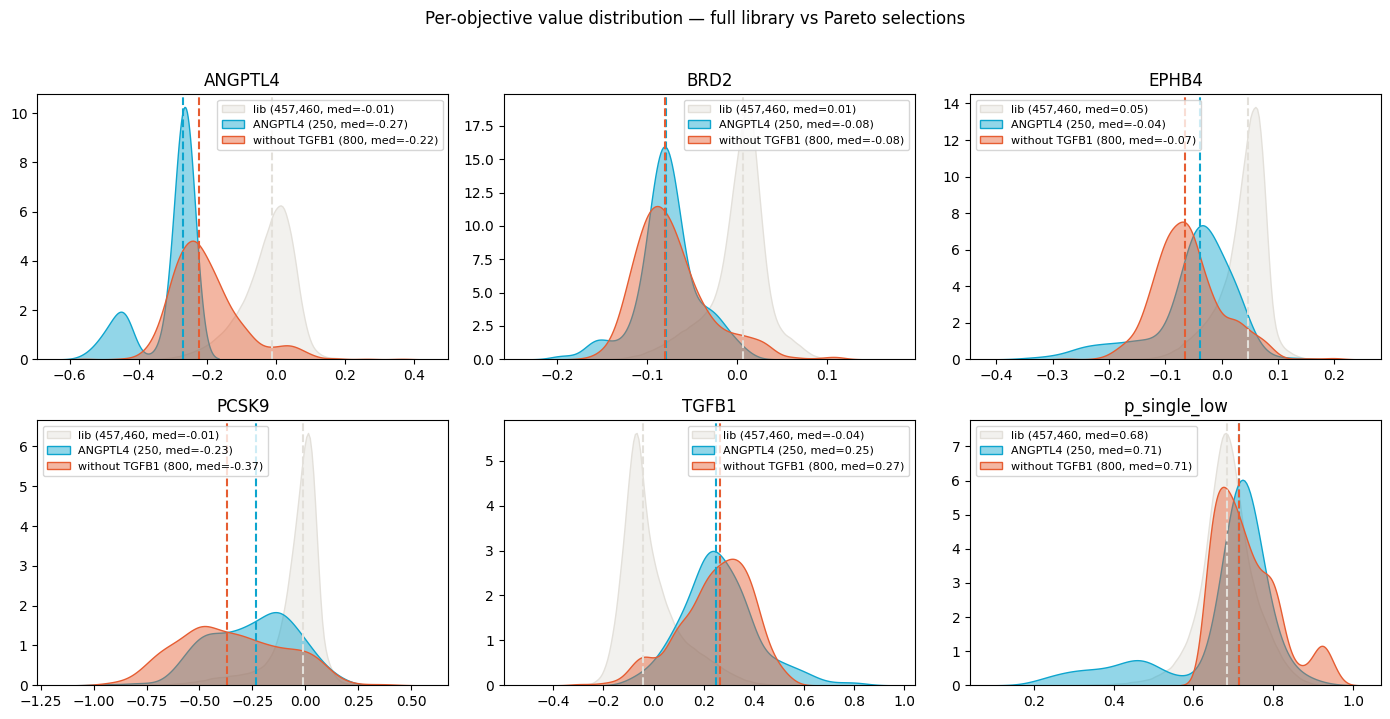

In [24]:
mlp.plot_objective_kde(
    objs,
    [final_pred, ANGPTL4_df,prio_noTGF],
    [SERAC_C['paper'], SERAC_C['azure'], SERAC_C['ember']],
    ['lib', objs[0],'without TGFB1'], dpi=100
);

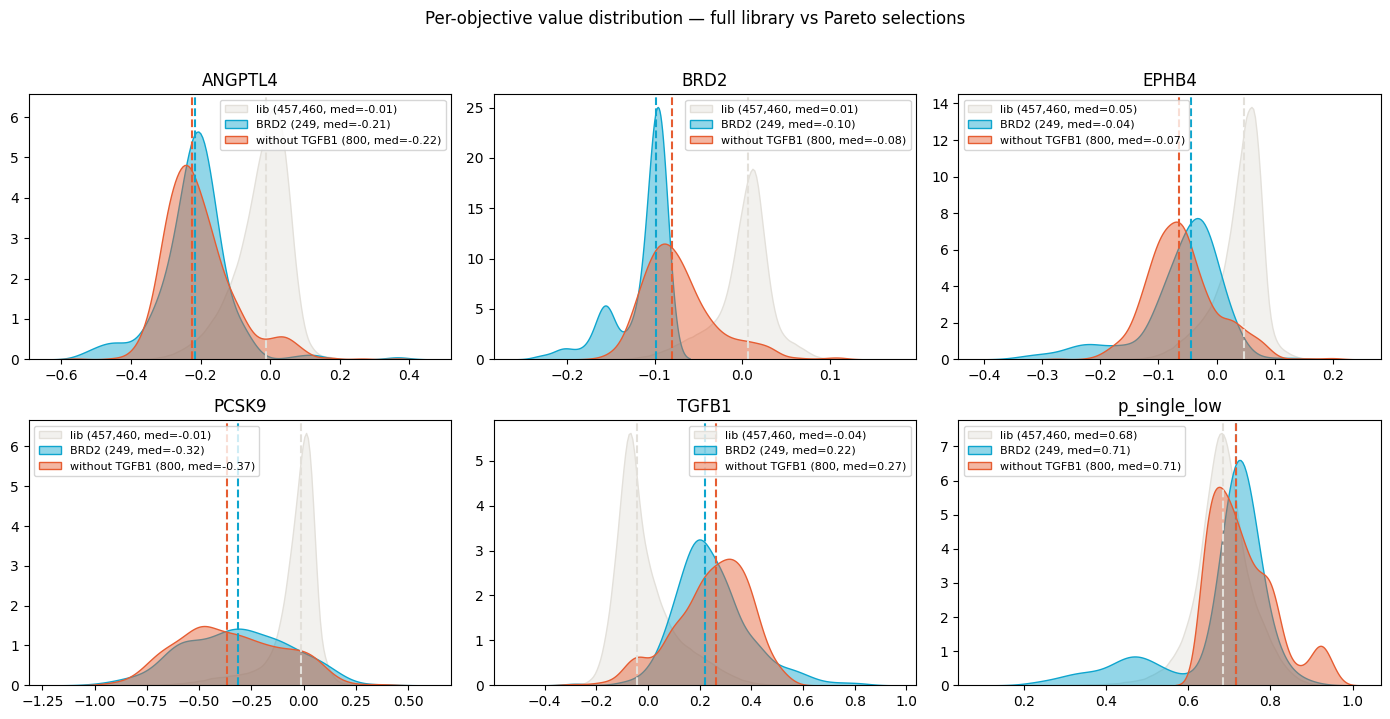

In [25]:
mlp.plot_objective_kde(
    objs,
    [final_pred, BRD2_df,prio_noTGF],
    [SERAC_C['paper'], SERAC_C['azure'], SERAC_C['ember']],
    ['lib', objs[1],'without TGFB1'], dpi=100
);

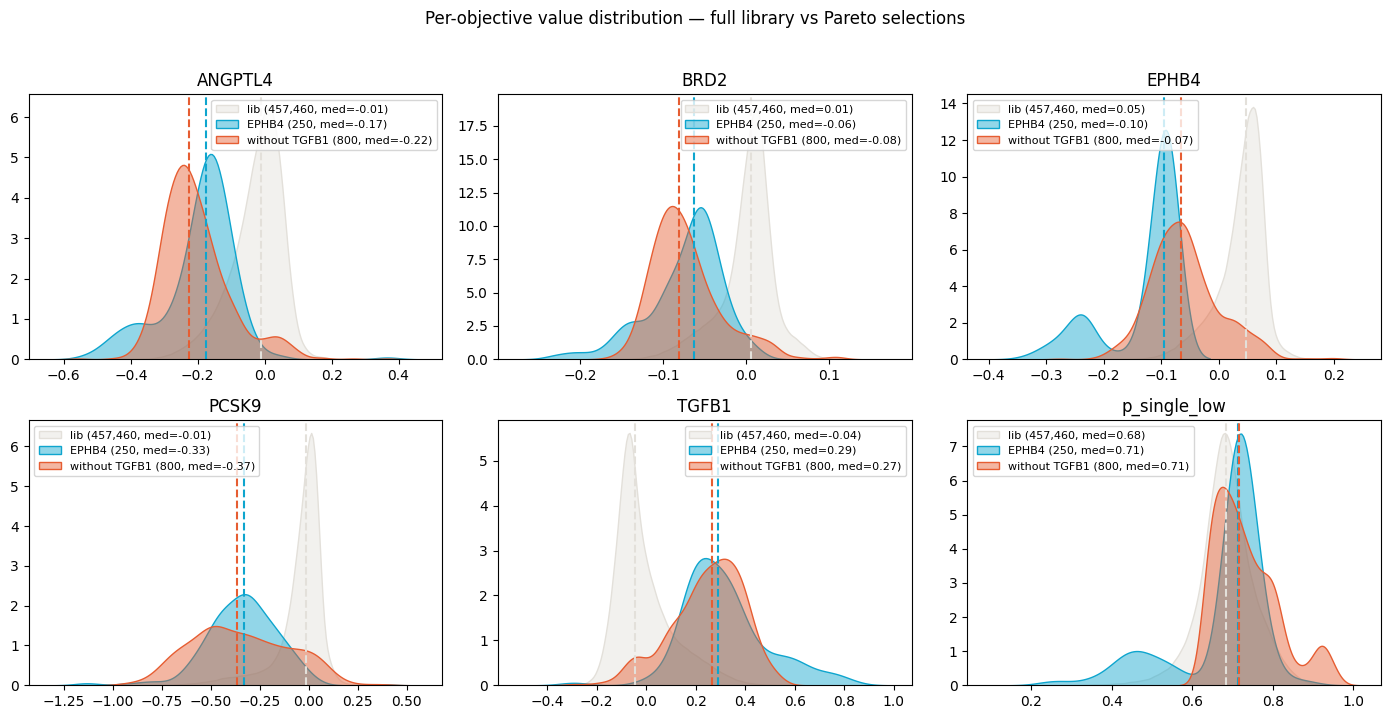

In [26]:
mlp.plot_objective_kde(
    objs,
    [final_pred, EPHB4_df,prio_noTGF],
    [SERAC_C['paper'], SERAC_C['azure'], SERAC_C['ember']],
    ['lib', objs[2],'without TGFB1'], dpi=100
);

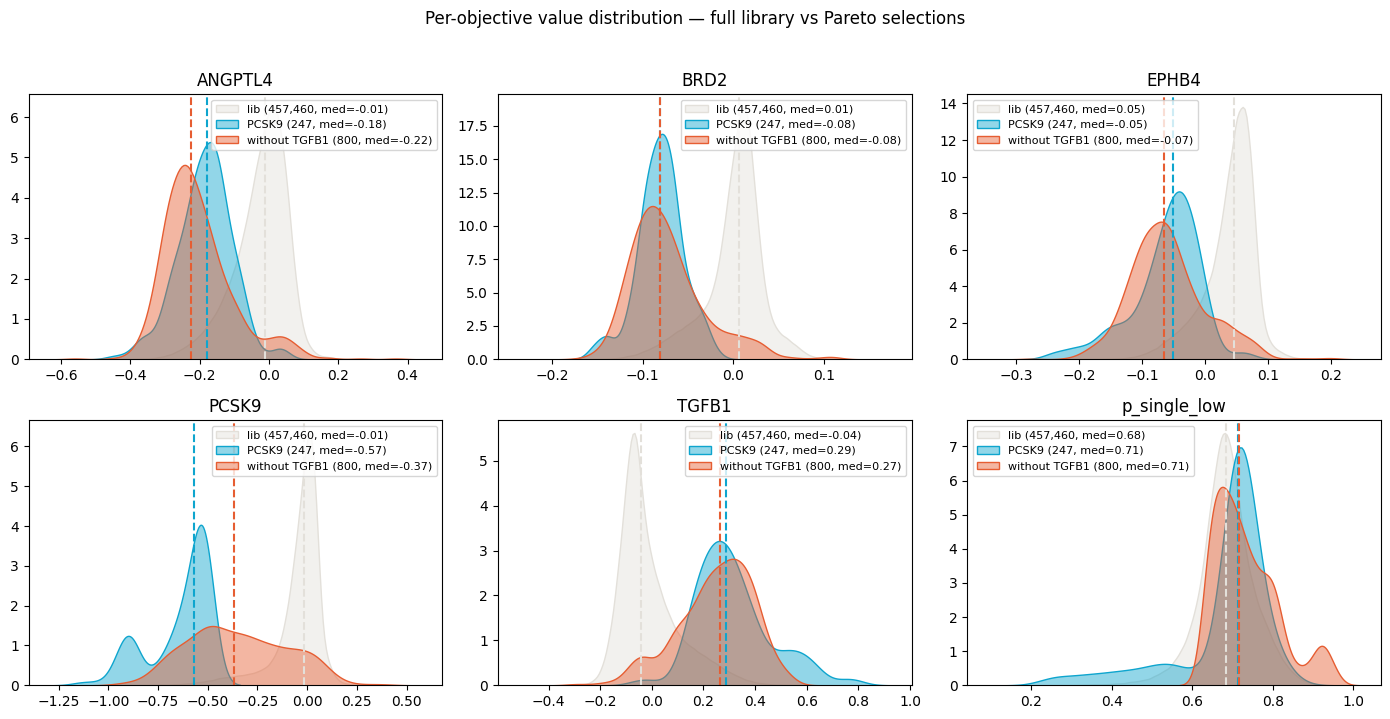

In [27]:
mlp.plot_objective_kde(
    objs,
    [final_pred, PCSK9_df,prio_noTGF],
    [SERAC_C['paper'], SERAC_C['azure'], SERAC_C['ember']],
    ['lib', objs[3],'without TGFB1'], dpi=100
);

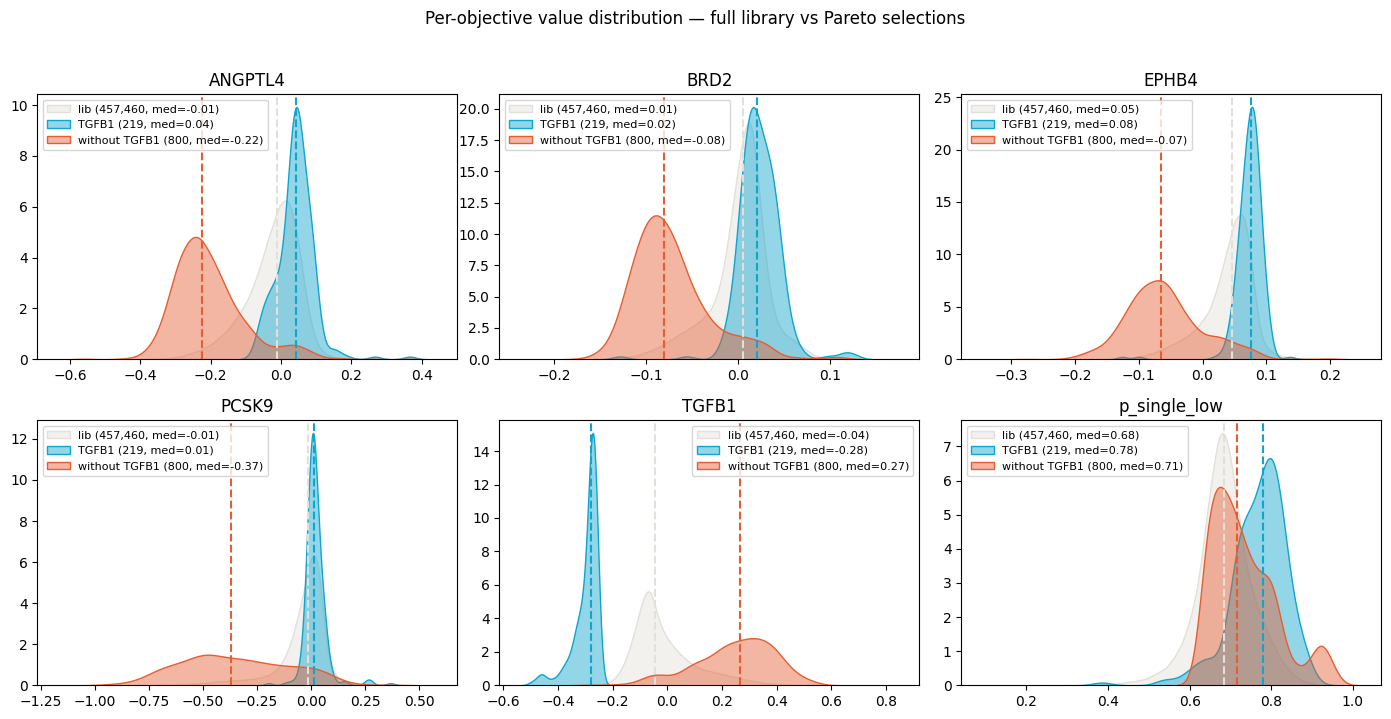

In [28]:
mlp.plot_objective_kde(
    objs,
    [final_pred, TGFB1_df,prio_noTGF],
    [SERAC_C['paper'], SERAC_C['azure'], SERAC_C['ember']],
    ['lib', objs[4],'without TGFB1'], dpi=100
);

In [30]:
deliverable.to_csv(DROPBOX_ML+'predictions/Enamine_Library_15_(Echoes)_working_files/20260624_SingleLow_5Targets_1K_from_550Kenum.csv',sep=',',index=False)

#### 20260624 Interface prioritization of compounds to be sent for FBX validation

In [50]:
dropbox_f = DROPBOX_ML+'interfaces/selection/20260624/20260624_MS_validation_cmps_NN.csv'
full_sel = pd.read_csv(dropbox_f)
full_sel.shape

(150, 9)

In [51]:
stock = pd.read_excel('/mnt/c/Users/gtamo/Serac Biosciences Dropbox/Serac_team/8_Data_Warehouse/Inventory/Inventory update for SRCBS_20260618.xlsx', sheet_name='Solid(II)')
# non-numeric stock amounts -> 0.0
stock['Stock Amount(mg)'] = pd.to_numeric(stock['Stock Amount(mg)'], errors='coerce').fillna(0.0)

In [52]:
full_sel[full_sel[ 'Batch Molecule-Batch ID'].isin(stock[stock['Stock Amount(mg)']>0.0]['Batch Molecule Batch ID'])].reset_index(drop=True).shape

(150, 9)

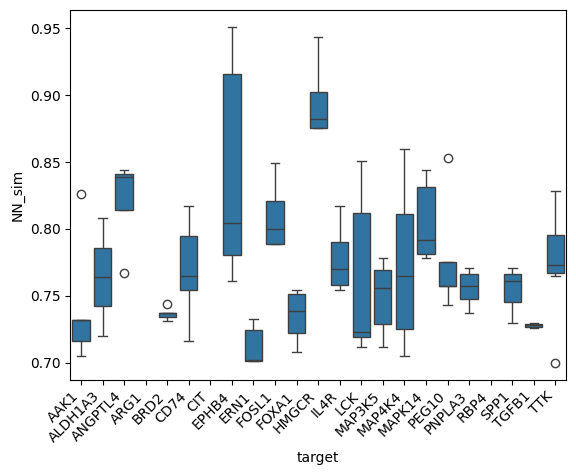

In [ ]:
## check the NN selection done by Florent
_ax = sns.boxplot(x='target', y='NN_sim', data=full_sel)
_tmp = _ax.set_xticklabels(_ax.get_xticklabels(), rotation=45, ha='right')

In [54]:
## split in two plates: 
seed_df = full_sel[full_sel['is_seed']==True].drop(['Molecule Name','is_seed','target','NN_sim','NN_partner','mol_smi'],axis=1).reset_index(drop=True)
analogs_df = full_sel[full_sel['is_seed']==False].drop(['Molecule Name','is_seed','genes','NN_sim','NN_partner','mol_smi','Activity'],axis=1).reset_index(drop=True)

In [55]:
seed_df.to_csv(DROPBOX_ML+'interfaces/selection/20260624/20260624_MS_validation_FBX_dependency.csv',index=False,sep=',')
analogs_df.to_csv(DROPBOX_ML+'interfaces/selection//20260624/20260624_MS_validation_NN_analogs.csv',index=False,sep=',')